In [13]:
pip install polars



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import polars as pl

In [5]:
# Leer el archivo parquet
dfinv = pl.read_parquet("/Users/cesarhernandezgarcia/Downloads/inventarios.parquet")

# Mostrar las primeras filas
print(dfinv.head())
dfven = pl.read_parquet('/Applications/ventas.parquet')
print(dfven.head(12))



shape: (5, 8)
┌────────────┬────────────┬────────────┬──────────┬────────────┬───────────┬───────────┬───────────┐
│ ClaveSucur ┆ IdArticulo ┆ Existencia ┆ Costo    ┆ ListaPreci ┆ ListaPrec ┆ ListaPrec ┆ Fecha     │
│ sal        ┆ ---        ┆ ---        ┆ ---      ┆ os1        ┆ ios2      ┆ ios3      ┆ ---       │
│ ---        ┆ i64        ┆ f64        ┆ f64      ┆ ---        ┆ ---       ┆ ---       ┆ str       │
│ i64        ┆            ┆            ┆          ┆ f64        ┆ f64       ┆ f64       ┆           │
╞════════════╪════════════╪════════════╪══════════╪════════════╪═══════════╪═══════════╪═══════════╡
│ 3          ┆ 1          ┆ 744.0      ┆ 530.4464 ┆ null       ┆ null      ┆ null      ┆ 2023-09-0 │
│            ┆            ┆            ┆          ┆            ┆           ┆           ┆ 1         │
│ 3          ┆ 1          ┆ 731.0      ┆ 530.4464 ┆ null       ┆ null      ┆ null      ┆ 2023-09-0 │
│            ┆            ┆            ┆          ┆            ┆           ┆ 

In [16]:
pip install ydata-profiling



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
pip install numpy



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [19]:
dfven.columns

['Fecha',
 'ClaveSucursal',
 'ClaveVendedor',
 'ClaveCliente',
 'ClaveFormatoVenta',
 'FolioFactura',
 'IdArticulo',
 'UnidadPedido',
 'UnidadFactura',
 'UnidadDevolucion',
 'ImporteFactura',
 'ImporteDevolucion',
 'ImporteNotaCredito']

In [20]:
dfinv.columns

['ClaveSucursal',
 'IdArticulo',
 'Existencia',
 'Costo',
 'ListaPrecios1',
 'ListaPrecios2',
 'ListaPrecios3',
 'Fecha']

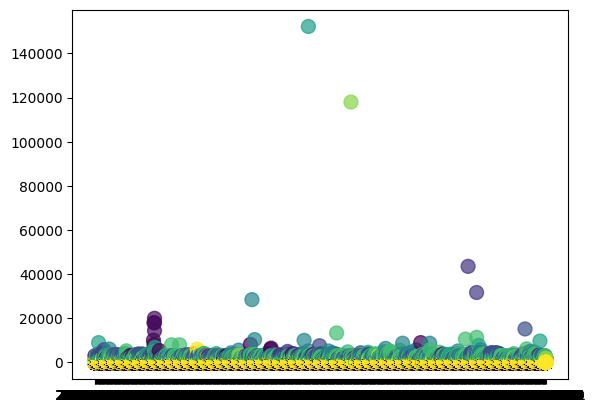

In [21]:
plt.scatter(x = 'Fecha', y = 'UnidadPedido', data = dfven, alpha = 0.7, c = dfven["ClaveSucursal"], cmap='viridis', s=100)
# 'c' define la variable que dicta el color y 'cmap' el estilo del degradado
plt.show()

In [22]:
dfven_6 = dfven.filter(pl.col('UnidadPedido') < 6000)

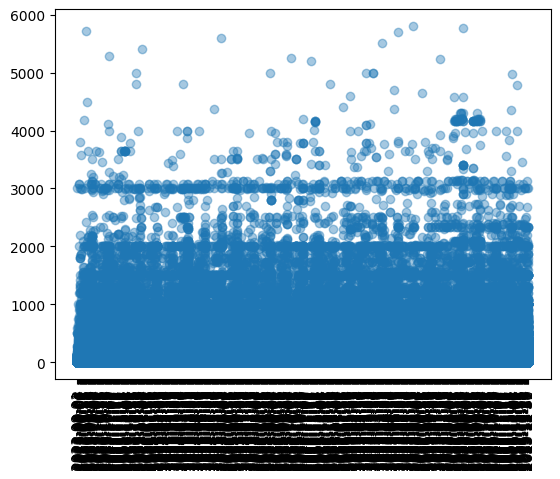

In [23]:
plt.scatter(x = 'Fecha', y = 'UnidadPedido', data = dfven_6, alpha = 0.4)
plt.xticks(rotation=90)
plt.show()

In [18]:
dfven_2024 = dfven.filter(pl.col('Fecha') < "2024")

In [25]:
dfven_2024["ClaveSucursal"].value_counts().unique()

ClaveSucursal,count
i64,u32
11,58596
51,106394
18,47114
45,117078
28,227337
…,…
63,3103
72,118006
29,148836


In [26]:
print(dfven_2024.sort("ClaveSucursal", descending=True))
#Ordenar la variable ClaveSucursal en orden descendiente

shape: (3_911_310, 13)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Fecha     ┆ ClaveSucu ┆ ClaveVend ┆ ClaveClie ┆ … ┆ UnidadDev ┆ ImporteFa ┆ ImporteDe ┆ ImporteN │
│ ---       ┆ rsal      ┆ edor      ┆ nte       ┆   ┆ olucion   ┆ ctura     ┆ volucion  ┆ otaCredi │
│ str       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ to       │
│           ┆ i64       ┆ i64       ┆ i64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2023-09-0 ┆ 102       ┆ 102000000 ┆ 102000022 ┆ … ┆ 0.0       ┆ 31.5      ┆ 0.0       ┆ 0.0      │
│ 1         ┆           ┆ 0002      ┆ 0002      ┆   ┆           ┆           ┆           ┆          │
│ 2023-09-0 ┆ 102       ┆ 102000000 ┆ 102000022 ┆ … ┆ 0.0       ┆ 81

In [27]:

dfven_2024_mitad = dfven.filter(pl.col('ClaveSucursal') <= 51)

In [ ]:
import polars as pl

# Agrupamos por Sucursal y sumamos las Unidades Pedidas
resultado = (
    dfven_2024_mitad
    .group_by("ClaveSucursal")
    .agg(pl.col("UnidadPedido").sum())
    .sort("UnidadPedido", descending=True) # Opcional: para ver la que más vendió primero
)
#.group_by("ClaveSucursal"): Toma tu tabla y junta en "pilas" todas las filas que pertenezcan a la misma sucursal.
#.agg(pl.col("UnidadPedido").sum()): Abreviatura de aggregate (agregar/calcular). Mira la pila de cada sucursal, va directo a la columna UnidadPedido y suma todos sus valores.
#.sort(..., descending=True): Te ordena el resultado final para que veas arriba de todo la sucursal que tuvo el valor más alto de unidades pedidas.

print(resultado)

shape: (20, 2)
┌───────────────┬──────────────┐
│ ClaveSucursal ┆ UnidadPedido │
│ ---           ┆ ---          │
│ i64           ┆ f64          │
╞═══════════════╪══════════════╡
│ 49            ┆ 1.9994151e7  │
│ 3             ┆ 1.8593766e7  │
│ 29            ┆ 1.083039e7   │
│ 26            ┆ 8.924072e6   │
│ 36            ┆ 8.258436e6   │
│ …             ┆ …            │
│ 11            ┆ 2.166496e6   │
│ 6             ┆ 2.13676e6    │
│ 33            ┆ 1.471553e6   │
│ 19            ┆ 926365.0     │
│ 35            ┆ 455221.0     │
└───────────────┴──────────────┘


In [29]:
sucursales_elegidas = [36, 26, 29, 3, 49]

# 2. Filtras usando .filter() y .is_in()
top5 = dfven_2024.filter(pl.col("ClaveSucursal").is_in(sucursales_elegidas))

print(top5)
#.filter(): Es la función nativa de Polars para evaluar condiciones y decidir qué filas se quedan y cuáles se van.
#----------------------------------------------------------------------------------------------------------------------
#.is_in(): Le dice a Polars: "Busca en la columna ClaveSucursal y quédate solo con los registros que estén dentro de mi 
#lista sucursales_elegidas". Es el equivalente al .isin() de Pandas.

shape: (1_348_557, 13)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Fecha     ┆ ClaveSucu ┆ ClaveVend ┆ ClaveClie ┆ … ┆ UnidadDev ┆ ImporteFa ┆ ImporteDe ┆ ImporteN │
│ ---       ┆ rsal      ┆ edor      ┆ nte       ┆   ┆ olucion   ┆ ctura     ┆ volucion  ┆ otaCredi │
│ str       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ to       │
│           ┆ i64       ┆ i64       ┆ i64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2023-09-0 ┆ 3         ┆ 300000000 ┆ 300000000 ┆ … ┆ 0.0       ┆ 266.37931 ┆ 0.0       ┆ 0.0      │
│ 1         ┆           ┆ 11        ┆ 11        ┆   ┆           ┆           ┆           ┆          │
│ 2023-09-0 ┆ 3         ┆ 300000000 ┆ 300000000 ┆ … ┆ 0.0       ┆ 29

#**top5 incluye sólo las 5 sucursales con más pedidos del año 2023**

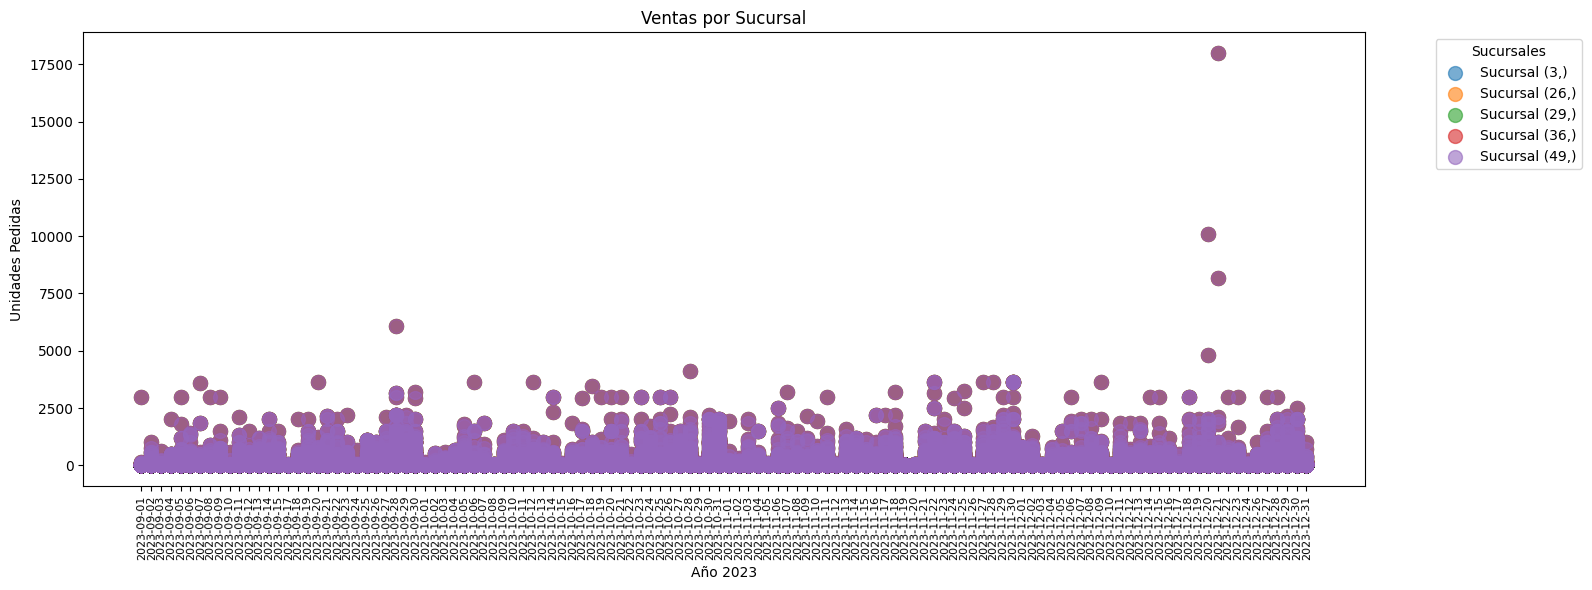

In [30]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Configurar la figura
fig, ax = plt.subplots(figsize=(16, 6))

# 2. Separar los datos por sucursal e iterar sobre cada una
# .partition_by("ClaveSucursal", as_dict=True) nos da un diccionario: {clave: sub_dataframe}
for sucursal, df_sub in top5.partition_by("ClaveSucursal", as_dict=True).items():
    ax.scatter(
        x=top5["Fecha"],
        y=top5["UnidadPedido"],
        alpha=0.6,
        s=100,
        label=f"Sucursal {sucursal}"  # Esto creará la etiqueta individual en la leyenda
    )

# 3. Formatear estéticos
plt.xticks(rotation=91)
ax.tick_params(axis='x', labelsize=8) # ax.tick_params(axis='x', labelsize=8),
#le estás ordenando a tu gráfica:"Ve al eje X, busca los textos de las etiquetas y encógelos a un tamaño de letra de 8 puntos".

plt.xlabel("Año 2023")
plt.ylabel("Unidades Pedidas")
plt.title("Ventas por Sucursal")

# 4. Mostrar la leyenda (ahora sí incluirá cada sucursal con su color)
plt.legend(title="Sucursales", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Evita que la leyenda se corte al guardarse o mostrarse

plt.show()

In [31]:
df49 = dfven_2024.filter(pl.col('ClaveSucursal') == 49)


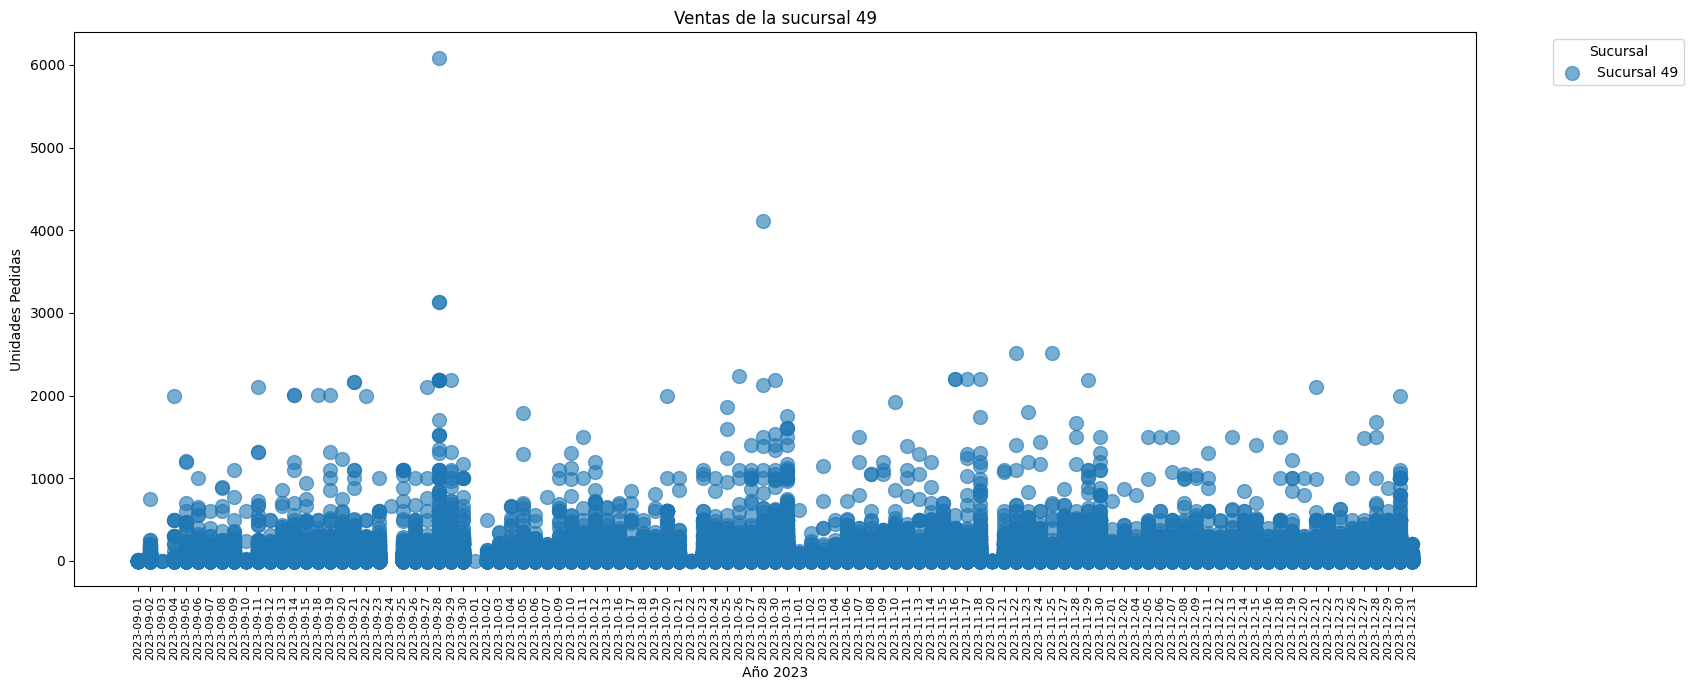

In [32]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Configurar la figura
fig, ax = plt.subplots(figsize=(17, 7))

# 2. Separar los datos por sucursal e iterar sobre cada una
# .partition_by("ClaveSucursal", as_dict=True) nos da un diccionario: {clave: sub_dataframe}

ax.scatter(
        x=df49["Fecha"],
        y=df49["UnidadPedido"],
        alpha=0.6,
        s=100,
        label="Sucursal 49"  # Esto creará la etiqueta individual en la leyenda
    )

# 3. Formatear estéticos
plt.xticks(rotation=90)
ax.tick_params(axis='x', labelsize=8)
plt.xlabel("Año 2023")
plt.ylabel("Unidades Pedidas")
plt.title("Ventas de la sucursal 49")

# 4. Mostrar la leyenda (ahora sí incluirá cada sucursal con su color)
plt.legend(title="Sucursal", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Evita que la leyenda se corte al guardarse o mostrarse

plt.show()

In [ ]:
import polars as pl

# Agrupamos por Sucursal y sumamos las Unidades Pedidas
resultado1 = (
    top5
    .group_by("Fecha")
    .agg(pl.col("UnidadPedido").sum())
    .sort("UnidadPedido", descending=True) # Opcional: para ver la que más vendió primero
)



print(resultado1.head(10))
#DÍAS CON MAYOR CANTIDAD DE VENTAS
#Los días que más se venden son los ultimos días de cada mes, del top 5. Esto en el año del 2023.

shape: (10, 2)
┌────────────┬──────────────┐
│ Fecha      ┆ UnidadPedido │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ 2023-11-30 ┆ 309451.0     │
│ 2023-10-31 ┆ 293815.0     │
│ 2023-12-30 ┆ 211780.0     │
│ 2023-09-30 ┆ 206133.0     │
│ 2023-11-29 ┆ 201132.0     │
│ 2023-12-29 ┆ 200339.0     │
│ 2023-09-28 ┆ 199651.0     │
│ 2023-10-30 ┆ 159923.0     │
│ 2023-09-29 ┆ 141706.0     │
│ 2023-11-24 ┆ 139061.0     │
└────────────┴──────────────┘


In [ ]:
#import matplotlib.pyplot as plt
#import seaborn as sns

# Nota que ahora solo hay un paréntesis al inicio y uno al final
#sns.regplot(
    #x=df49["Fecha"],
    #y=df49["UnidadPedido"],
    #scatter_kws={"color": "mediumblue", "alpha": 0.7},
    #line_kws={"color": "fuchsia"},
#)

#plt.show()

IndentationError: unexpected indent (2790446684.py, line 6)

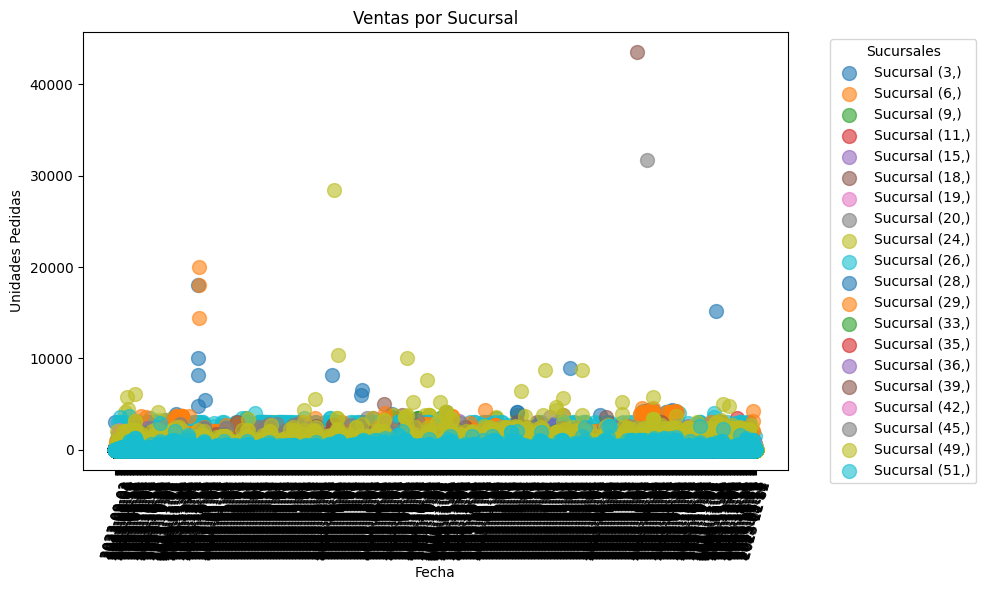

In [34]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Configurar la figura
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Separar los datos por sucursal e iterar sobre cada una
# .partition_by("ClaveSucursal", as_dict=True) nos da un diccionario: {clave: sub_dataframe}
for sucursal, df_sub in dfven_2024_mitad.partition_by("ClaveSucursal", as_dict=True).items():
    ax.scatter(
        x=df_sub["Fecha"],
        y=df_sub["UnidadPedido"],
        alpha=0.6,
        s=100,
        label=f"Sucursal {sucursal}"  # Esto creará la etiqueta individual en la leyenda
    )

# 3. Formatear estéticos
plt.xticks(rotation=75)
plt.xlabel("Fecha")
plt.ylabel("Unidades Pedidas")
plt.title("Ventas por Sucursal")

# 4. Mostrar la leyenda (ahora sí incluirá cada sucursal con su color)
plt.legend(title="Sucursales", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Evita que la leyenda se corte al guardarse o mostrarse

plt.show()

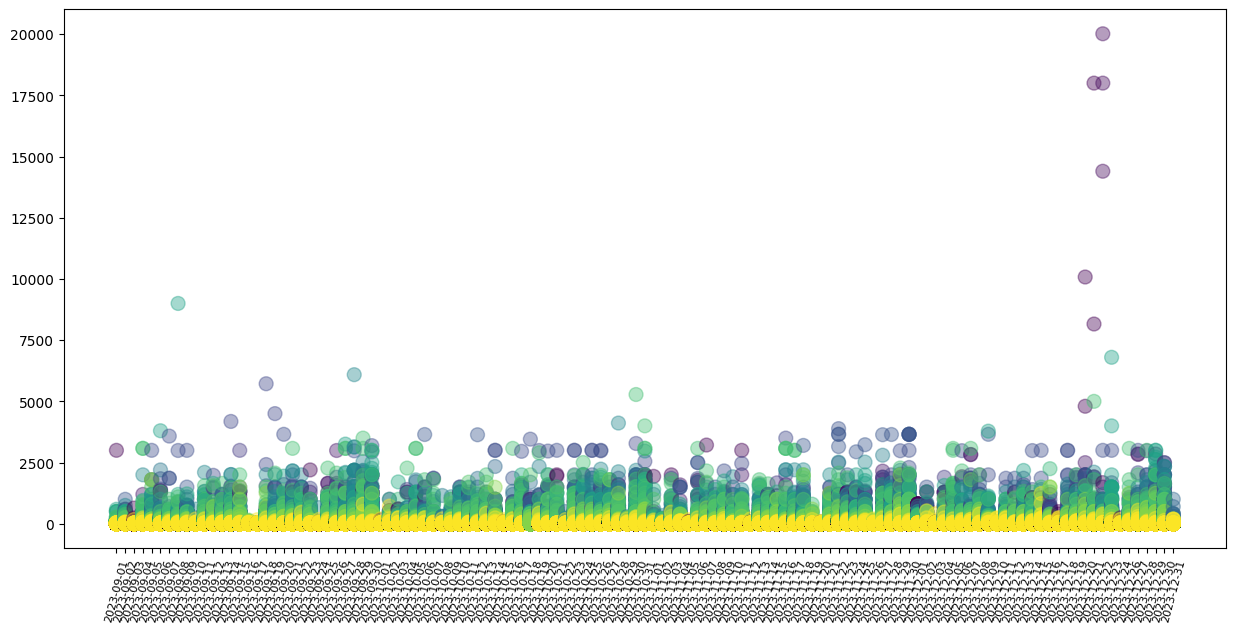

In [37]:
fig, aaa = plt.subplots(figsize=(15, 7))
plt.scatter(
    x = dfven_2024["Fecha"], 
    y = dfven_2024['UnidadPedido'], 
    alpha = 0.4, c = dfven_2024["ClaveSucursal"], 
    cmap='viridis', s=100
    )

plt.tick_params(axis='x', labelsize=8)
plt.xticks(rotation=75)
plt.show()

In [ ]:
dfven_2024['Fecha']

Fecha
str
"""2023-09-01"""
"""2023-09-01"""
"""2023-09-01"""
"""2023-09-01"""
"""2023-09-01"""
…
"""2023-12-31"""
"""2023-12-31"""
"""2023-12-31"""


In [61]:
año24 = ['2023', '2025']

In [70]:
dfven_2025 = dfven.filter(pl.col("Fecha") < "2025")

In [71]:
dfven_202555 = dfven_2025.filter(pl.col("Fecha") >= "2024")

In [72]:
dfven_202555

Fecha,ClaveSucursal,ClaveVendedor,ClaveCliente,ClaveFormatoVenta,FolioFactura,IdArticulo,UnidadPedido,UnidadFactura,UnidadDevolucion,ImporteFactura,ImporteDevolucion,ImporteNotaCredito
str,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64
"""2024-01-02""",3,30000000003,30000531979,20,899851,128688,300.0,300.0,0.0,26808.621,0.0,-170.691
"""2024-01-02""",3,30000000003,30000531979,20,899851,128694,50.0,50.0,0.0,4468.1035,0.0,-28.4485
"""2024-01-02""",3,30000000003,30000531979,20,899850,80376,30.0,30.0,0.0,6155.1723,0.0,-853.4484
"""2024-01-02""",3,30000000003,30000531979,20,899851,128689,300.0,300.0,0.0,26808.621,0.0,-170.691
"""2024-01-02""",3,30000000003,30000531979,20,899852,5964,15.0,15.0,0.0,5760.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…
"""2024-12-31""",102,1020000000009,1020000220009,60,456367,47578,12.0,12.0,0.0,173.4,0.0,0.0
"""2024-12-31""",102,1020000000009,1020000220009,60,456300,47642,3.0,3.0,0.0,0.03,0.0,0.0
"""2024-12-31""",102,1020000000009,1020000220009,60,456346,47642,1.0,1.0,0.0,0.01,0.0,0.0


In [ ]:

import polars as pl

# Agrupamos por Sucursal y sumamos las Unidades Pedidas
resultado1 = (
    dfven_2024
    .group_by("Fecha")
    .agg(pl.col("UnidadPedido").sum())
    .sort("UnidadPedido", descending=True) # Opcional: para ver la que más vendió primero
)



print(resultado1.head(10))

shape: (10, 2)
┌────────────┬──────────────┐
│ Fecha      ┆ UnidadPedido │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ 2023-10-31 ┆ 980975.0     │
│ 2023-11-30 ┆ 952929.0     │
│ 2023-09-30 ┆ 732288.0     │
│ 2023-12-30 ┆ 671549.0     │
│ 2023-12-29 ┆ 567776.0     │
│ 2023-11-29 ┆ 541134.0     │
│ 2023-09-29 ┆ 518760.0     │
│ 2023-09-28 ┆ 479033.0     │
│ 2023-10-30 ┆ 432042.0     │
│ 2023-11-28 ┆ 394361.0     │
└────────────┴──────────────┘


In [79]:
resultado1 = (
    dfven
    .group_by("Fecha")
    .agg(pl.col("UnidadPedido").sum())
    .sort("UnidadPedido", descending=True) # Opcional: para ver la que más vendió primero
)



print(resultado1.head(10))

shape: (10, 2)
┌────────────┬──────────────┐
│ Fecha      ┆ UnidadPedido │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ 2024-04-30 ┆ 1.11353e6    │
│ 2024-07-31 ┆ 1.017619e6   │
│ 2025-09-30 ┆ 998347.0     │
│ 2024-09-30 ┆ 998203.0     │
│ 2024-06-29 ┆ 993533.0     │
│ 2023-10-31 ┆ 980975.0     │
│ 2025-03-31 ┆ 973303.0     │
│ 2025-04-30 ┆ 968558.0     │
│ 2024-01-31 ┆ 966512.0     │
│ 2024-11-30 ┆ 966352.0     │
└────────────┴──────────────┘


In [115]:
dfven.columns

['Fecha',
 'ClaveSucursal',
 'ClaveVendedor',
 'ClaveCliente',
 'ClaveFormatoVenta',
 'FolioFactura',
 'IdArticulo',
 'UnidadPedido',
 'UnidadFactura',
 'UnidadDevolucion',
 'ImporteFactura',
 'ImporteDevolucion',
 'ImporteNotaCredito']

In [114]:
print(dfven.dtypes)


[String, Int64, Int64, Int64, Int64, Int64, Int64, Float64, Float64, Float64, Float64, Float64, Float64]


In [ ]:
import polars as pl

# Creamos la nueva columna con la resta
reso = dfven.with_columns(
    (pl.col("UnidadPedido") - pl.col("UnidadFactura")).alias("Diferencia")
)

print(reso)
#.with_columns(...): Le dice a Polars: "Quiero agregar una nueva columna a mi DataFrame actual (o modificar una existente)".
#pl.col("ColumnaA") - pl.col("ColumnaB"): Es la operación matemática directa. Polars va a restar los valores fila por fila de forma ultra rápida.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------
#.alias("Diferencia"): Este paso es vital. Sirve para ponerle el nombre a tu nueva columna. 
#Si no usas .alias(), Polars nombrará la columna con toda la operación matemática literal y se verá muy feo (algo como col("ColumnaA") - col("ColumnaB")).

shape: (27_720_332, 14)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Fecha     ┆ ClaveSucu ┆ ClaveVend ┆ ClaveClie ┆ … ┆ ImporteFa ┆ ImporteDe ┆ ImporteNo ┆ Diferenc │
│ ---       ┆ rsal      ┆ edor      ┆ nte       ┆   ┆ ctura     ┆ volucion  ┆ taCredito ┆ ia       │
│ str       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆ i64       ┆ i64       ┆ i64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2023-09-0 ┆ 3         ┆ 300000000 ┆ 300000000 ┆ … ┆ 266.37931 ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ 1         ┆           ┆ 11        ┆ 11        ┆   ┆           ┆           ┆           ┆          │
│ 2023-09-0 ┆ 3         ┆ 300000000 ┆ 300000000 ┆ … ┆ 292.5926  ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ 1         ┆           ┆ 11        ┆ 11        ┆   ┆           ┆  

In [119]:
reso['Diferencia'].describe()

statistic,value
str,f64
"""count""",2.7720332e7
"""null_count""",0.0
"""mean""",0.180766
"""std""",39.096331
"""min""",-4.0
"""25%""",0.0
"""50%""",0.0
"""75%""",0.0
"""max""",152100.0


In [122]:
dfinv.columns

['ClaveSucursal',
 'IdArticulo',
 'Existencia',
 'Costo',
 'ListaPrecios1',
 'ListaPrecios2',
 'ListaPrecios3',
 'Fecha']

#Modelo Machine Learning

In [81]:
import pandas as pd

In [14]:
dfven.head()

Fecha,ClaveSucursal,ClaveVendedor,ClaveCliente,ClaveFormatoVenta,FolioFactura,IdArticulo,UnidadPedido,UnidadFactura,UnidadDevolucion,ImporteFactura,ImporteDevolucion,ImporteNotaCredito
str,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64
"""2023-09-01""",3,30000000011,30000000011,10,781103,10349,1.0,1.0,0.0,266.37931,0.0,0.0
"""2023-09-01""",3,30000000011,30000000011,10,780491,13072,2.0,2.0,0.0,292.5926,0.0,0.0
"""2023-09-01""",3,30000000011,30000000011,10,780444,33834,2.0,2.0,0.0,744.82758,0.0,0.0
"""2023-09-01""",3,30000000011,30000000011,10,781370,57334,1.0,1.0,0.0,96.0,0.0,0.0
"""2023-09-01""",3,30000000011,30000000011,10,781334,82320,1.0,1.0,0.0,175.0,0.0,0.0


In [15]:
dfinv.head()


ClaveSucursal,IdArticulo,Existencia,Costo,ListaPrecios1,ListaPrecios2,ListaPrecios3,Fecha
i64,i64,f64,f64,f64,f64,f64,str
3,1,744.0,530.4464,null,null,null,"""2023-09-01"""
3,1,731.0,530.4464,null,null,null,"""2023-09-02"""
3,1,730.0,530.4464,null,null,null,"""2023-09-03"""
3,1,719.0,530.4464,null,null,null,"""2023-09-04"""
3,1,668.0,530.4464,null,null,null,"""2023-09-05"""


In [138]:
y1 = dfven_2024[["ImporteFactura"]]
x1 = dfven_2024[['UnidadDevolucion','ImporteNotaCredito', 'ClaveSucursal']]

In [21]:
pip install scikit-learn


  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/49/d8/9be608c6024d021041c7f0b3928d4749a706f4e2c3832bbede4fb4f58c95/scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.2.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 22.2 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [139]:
from sklearn.tree import DecisionTreeRegressor
melbourne_model = DecisionTreeRegressor()
melbourne_model.fit(x1, y1)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [123]:
print('Datos para las primeras diez ventas: ')
print(x1.head(10))


Datos para las primeras diez ventas: 
shape: (10, 3)
┌──────────────────┬────────────────────┬───────────────┐
│ UnidadDevolucion ┆ ImporteNotaCredito ┆ ClaveSucursal │
│ ---              ┆ ---                ┆ ---           │
│ f64              ┆ f64                ┆ i64           │
╞══════════════════╪════════════════════╪═══════════════╡
│ 0.0              ┆ 0.0                ┆ 3             │
│ 0.0              ┆ 0.0                ┆ 3             │
│ 0.0              ┆ 0.0                ┆ 3             │
│ 0.0              ┆ 0.0                ┆ 3             │
│ 0.0              ┆ 0.0                ┆ 3             │
│ 0.0              ┆ 0.0                ┆ 3             │
│ 0.0              ┆ 0.0                ┆ 3             │
│ 0.0              ┆ 0.0                ┆ 3             │
│ 0.0              ┆ 0.0                ┆ 3             │
│ 0.0              ┆ 0.0                ┆ 3             │
└──────────────────┴────────────────────┴───────────────┘


In [ ]:
print('El importe real es: ')
print(y1.head())

El precio real es: 
shape: (5, 1)
┌────────────────┐
│ ImporteFactura │
│ ---            │
│ f64            │
╞════════════════╡
│ 266.37931      │
│ 292.5926       │
│ 744.82758      │
│ 96.0           │
│ 175.0          │
└────────────────┘


In [133]:
print('Las predicciones son: ')
print(melbourne_model.predict(x1.head()))

Las predicciones son: 
[42.53890667 64.01884138 64.01884138 42.53890667 42.53890667]


In [140]:
from sklearn.metrics import mean_absolute_error

predicted_importe = melbourne_model.predict(x1)
mean_absolute_error(y1, predicted_importe)

620.4868984015538

In [144]:
from sklearn.model_selection import train_test_split

train_x1, val_x1, train_y1, val_y1 = train_test_split(x1, y1)

melbourne_model = DecisionTreeRegressor()
melbourne_model.fit(train_x1, train_y1)

val_predictiones = melbourne_model.predict(val_x1)
print(mean_absolute_error(val_y1, val_predictiones))

1020.7315284747507
